# **Centrality Analyses**

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt

/home/david/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
def get_continent(latitude: float, longitude: float) -> str:
    if latitude <= -60:
        return "Antarctica"

    # Južná Amerika
    if -56 <= latitude <= 13 and -82 <= longitude <= -34:
        return "South America"

    # Severná Amerika
    if 7 <= latitude <= 84 and -168 <= longitude <= -50:
        return "North America"

    # Európa
    if 35 <= latitude <= 72 and -25 <= longitude <= 60:
        return "Europe"

    # Afrika
    if -35 <= latitude <= 37 and -18 <= longitude <= 52:
        return "Africa"

    # Ázia
    if 1 <= latitude <= 77 and 26 <= longitude <= 180:
        return "Asia"

    # Austrália / Oceánia
    if -50 <= latitude <= 10 and (110 <= longitude <= 180 or -180 <= longitude <= -140):
        return "Australia / Oceania"

    return "Unknown continent"

In [3]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country", " latitude", " longitude"]]
nodes[" id"] = np.arange(0, 3214)

In [4]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [5]:
A = np.array([[0 for i in range(3214)] for i in range(3214)])

assert len(source_airport) == len(destination_airport)

for source, target, distance in edges.values:
    A[np.int16(source)][np.int16(target)] = distance


In [6]:
G = nx.from_numpy_array(A, create_using=nx.DiGraph)

In [7]:
def print_top_centrality(centrality_dict, nodes_df, top_n=10):
    id_to_name = dict(zip(nodes_df[" id"].astype(int), nodes_df[" name"]))
    centrality_list = [(int(n), float(s), id_to_name.get(int(n), "Unknown")) for n, s in centrality_dict.items()]
    centrality_list_sorted = sorted(centrality_list, key=lambda x: x[1], reverse=True)
    for i, (nid, score, name) in enumerate(centrality_list_sorted[:top_n], 1):
        print(f"{i}. {name} (id={nid}): {score:.6f}")

# **Distance centrality**

In [8]:
distance_centrality = nx.degree_centrality(G)
print_top_centrality(distance_centrality, nodes)

1. Frankfurt am Main Airport (id=191): 0.148459
2. Charles de Gaulle International Airport (id=628): 0.146281
3. Amsterdam Airport Schiphol (id=282): 0.144102
4. Atatürk International Airport (id=770): 0.140367
5. Hartsfield Jackson Atlanta International Airport (id=1809): 0.134765
6. Chicago O'Hare International Airport (id=1885): 0.127295
7. Beijing Capital International Airport (id=1642): 0.126984
8. Munich Airport (id=196): 0.118270
9. Domodedovo International Airport (id=2016): 0.116713
10. Dallas Fort Worth International Airport (id=1800): 0.115780


# Betweenness Centrality

In [9]:
betweenness_centrality = nx.betweenness_centrality(G)
print_top_centrality(betweenness_centrality, nodes)

1. Charles de Gaulle International Airport (id=628): 0.063393
2. Los Angeles International Airport (id=1715): 0.061071
3. Dubai International Airport (id=1017): 0.058113
4. Ted Stevens Anchorage International Airport (id=1861): 0.054545
5. Frankfurt am Main Airport (id=191): 0.052293
6. Beijing Capital International Airport (id=1642): 0.049383
7. Chicago O'Hare International Airport (id=1885): 0.045669
8. Lester B. Pearson International Airport (id=125): 0.044323
9. Amsterdam Airport Schiphol (id=282): 0.044237
10. Atatürk International Airport (id=770): 0.041751


# Eigenvector centrality

In [10]:
eigenvector_centrality = nx.eigenvector_centrality(G)
print_top_centrality(eigenvector_centrality, nodes)

1. Amsterdam Airport Schiphol (id=282): 0.165988
2. Frankfurt am Main Airport (id=191): 0.165793
3. Charles de Gaulle International Airport (id=628): 0.159272
4. Munich Airport (id=196): 0.149033
5. London Heathrow Airport (id=255): 0.136871
6. Leonardo da Vinci–Fiumicino Airport (id=706): 0.135915
7. Barcelona International Airport (id=570): 0.129525
8. Atatürk International Airport (id=770): 0.129509
9. Zürich Airport (id=758): 0.126253
10. Adolfo Suárez Madrid–Barajas Airport (id=578): 0.123318


# Closeness centrality

In [11]:
closeness_centrality = nx.closeness_centrality(G)
print_top_centrality(closeness_centrality, nodes)

1. Frankfurt am Main Airport (id=191): 0.405614
2. Charles de Gaulle International Airport (id=628): 0.403153
3. London Heathrow Airport (id=255): 0.400979
4. Dubai International Airport (id=1017): 0.395847
5. Amsterdam Airport Schiphol (id=282): 0.395647
6. Los Angeles International Airport (id=1715): 0.389140
7. John F Kennedy International Airport (id=1870): 0.388898
8. Lester B. Pearson International Airport (id=125): 0.383786
9. Atatürk International Airport (id=770): 0.383550
10. Munich Airport (id=196): 0.382798


# Katz centrality

In [12]:
katz_centrality = nx.katz_centrality(G, alpha=0.005)
print_top_centrality(katz_centrality, nodes)

1. Frankfurt am Main Airport (id=191): 0.045092
2. Amsterdam Airport Schiphol (id=282): 0.044299
3. Charles de Gaulle International Airport (id=628): 0.044289
4. Atatürk International Airport (id=770): 0.041845
5. Munich Airport (id=196): 0.039603
6. Hartsfield Jackson Atlanta International Airport (id=1809): 0.039146
7. Beijing Capital International Airport (id=1642): 0.038853
8. Chicago O'Hare International Airport (id=1885): 0.038634
9. London Heathrow Airport (id=255): 0.038289
10. Dubai International Airport (id=1017): 0.037214


In [13]:
data = {
    'degree': distance_centrality,
    'betweenness': betweenness_centrality,
    'closeness': closeness_centrality,
    'eigenvector': eigenvector_centrality,
    'katz': katz_centrality
}

df = pd.DataFrame(data)

# Reset index
df = df.reset_index().rename(columns={'index': 'node_id'})

nodes_clean = nodes.copy()
nodes_clean.columns = nodes_clean.columns.str.strip()
df = df.merge(nodes_clean[["id", "name", "country"]], left_on="node_id", right_on="id", how="left")

df = df.drop(columns=['id']).rename(columns={'name': 'airport_name'})

# Normalize
cols_to_norm = ['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']
df_norm = df.copy()
for col in cols_to_norm:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

df_norm

,node_id,degree,betweenness,closeness,eigenvector,katz,airport_name,country
0,0,0.014706,0.000000,0.553710,3.287370e-04,0.011906,Goroka Airport,Papua New Guinea
1,1,0.027311,0.000011,0.553830,3.428181e-04,0.020314,Madang Airport,Papua New Guinea
2,2,0.033613,0.000029,0.553909,3.517469e-04,0.025847,Mount Hagen Kagamuga Airport,Papua New Guinea
3,3,0.035714,0.000031,0.553909,3.565146e-04,0.025934,Nadzab Airport,Papua New Guinea
4,4,0.132353,0.228391,0.716772,2.171409e-02,0.103049,Port Moresby Jacksons International Airport,Papua New Guinea
...,...,...,...,...,...,...,...,...
3209,3209,0.002101,0.004844,0.387560,1.617725e-07,0.002785,Kongolo Airport,Congo (Kinshasa)
3210,3210,0.002101,0.000000,0.505514,1.776011e-04,0.002900,Tarko-Sale Airport,Russia
3211,3211,0.014706,0.000014,0.560848,2.314649e-03,0.013879,Jinchuan Airport,China
3212,3212,0.002101,0.000000,0.569474,1.236664e-03,0.003766,Alashankou Bole (Bortala) airport,China


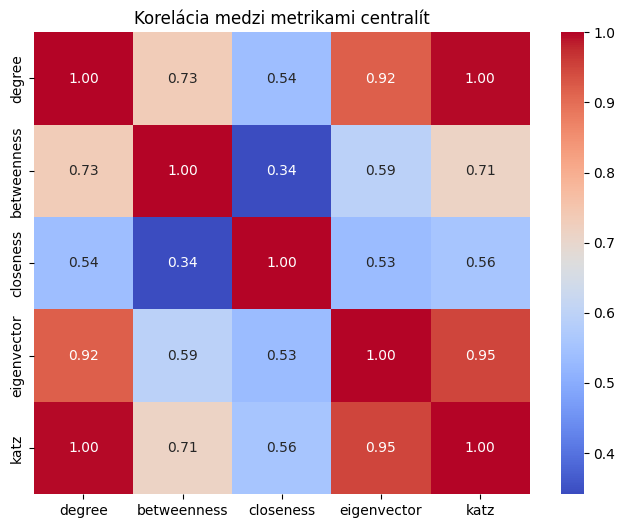

In [14]:
corr = df_norm[['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Korelácia medzi metrikami centralít")
plt.show()

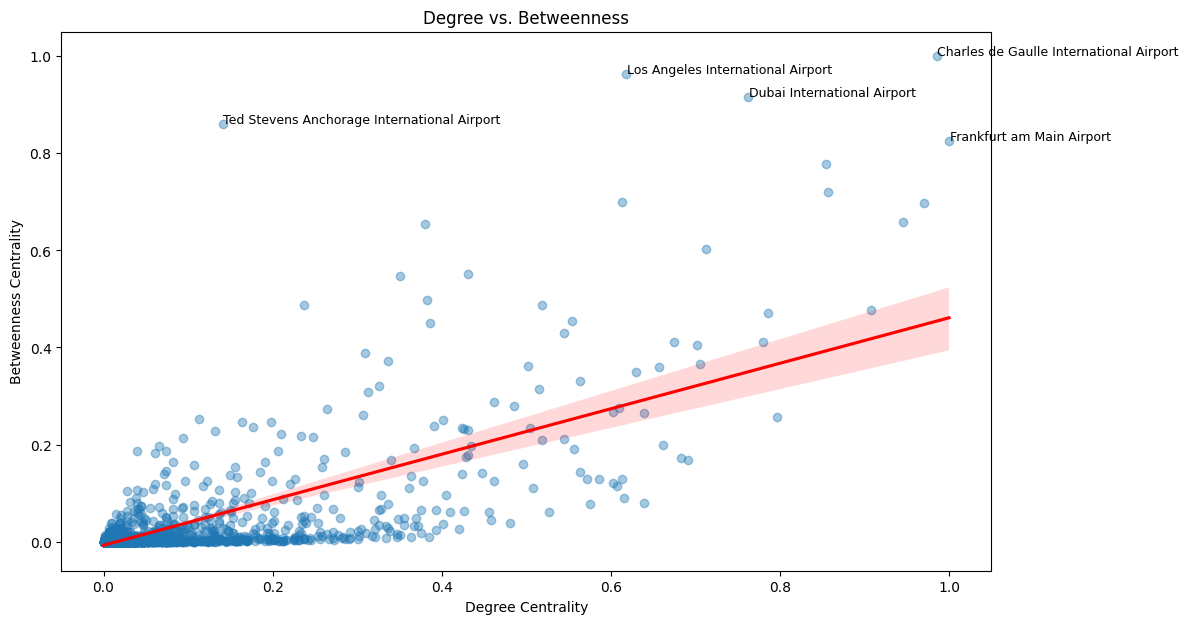

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.regplot(x='degree', y='betweenness', data=df_norm, 
            scatter_kws={'alpha':0.4}, line_kws={'color':'red', 'label':'Trend'})

for i in range(len(df_norm)):
    if df_norm['betweenness'].iloc[i] > 0.8 and df_norm['degree'].iloc[i] > 0.07:
        plt.text(df_norm['degree'].iloc[i] + 0.001, 
                 df_norm['betweenness'].iloc[i] + 0.001, 
                 df_norm['airport_name'].iloc[i],
                 fontsize=9)

plt.title("Degree vs. Betweenness")
plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
# plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [16]:
# 1. Výpočet Bridge Indexu (pomer dôležitosti k veľkosti)
df_norm['bridge_index'] = df_norm['betweenness'] / (df_norm['degree'] + 0.001)

df_norm['regional_index'] = df_norm['degree'] - df_norm['betweenness']

df_norm['prestige_index'] = df_norm['eigenvector'] / (df_norm['degree'] + 0.001)

df_norm['local_giant_index'] = df_norm['degree'] - df_norm['eigenvector']


In [17]:
top_10_bridges = df_norm.sort_values('bridge_index', ascending=False)
top_10_bridges

,node_id,degree,betweenness,closeness,eigenvector,katz,airport_name,country,bridge_index,regional_index,prestige_index,local_giant_index
1861,1861,0.140756,0.860425,0.730507,4.226761e-02,0.118010,Ted Stevens Anchorage International Airport,United States,6.069751,-0.719669,2.981709e-01,0.098489
3058,3058,0.002101,0.014518,0.001151,7.498771e-37,0.002771,Minaçu Airport,Brazil,4.681899,-0.012417,2.418303e-34,0.002101
73,73,0.039916,0.187518,0.685508,9.089062e-03,0.034589,Thunder Bay Airport,Canada,4.583015,-0.147603,2.221397e-01,0.030827
464,464,0.008403,0.038658,0.568256,7.651344e-04,0.008691,Bangoka International Airport,Congo (Kinshasa),4.111045,-0.030254,8.136818e-02,0.007638
2292,2292,0.006303,0.029013,0.438504,1.797928e-06,0.005585,Fort Albany Airport,Canada,3.972973,-0.022710,2.462065e-04,0.006301
...,...,...,...,...,...,...,...,...,...,...,...,...
432,432,0.006303,0.000000,0.603148,1.891881e-03,0.006336,Kuito Airport,Angola,0.000000,0.006303,2.590723e-01,0.004411
431,431,0.010504,0.000000,0.603196,1.919595e-03,0.009139,Nova Lisboa Airport,Angola,0.000000,0.010504,1.668604e-01,0.008585
430,430,0.006303,0.000000,0.603148,1.890225e-03,0.006280,Cabinda Airport,Angola,0.000000,0.006303,2.588455e-01,0.004412
429,429,0.002101,0.000000,0.603101,1.862935e-03,0.003491,Mbanza Congo Airport,Angola,0.000000,0.002101,6.007838e-01,0.000238


In [18]:
top_10_bridges["continent"] = top_10_bridges.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
top_10_bridges["continent"][:13].value_counts()

continent
North America    9
South America    3
Africa           1
Name: count, dtype: int64

In [19]:
cols_to_sum = ['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']
df_norm['global_hub_score'] = df_norm[cols_to_sum].mean(axis=1)

global_hubs = df_norm.sort_values('global_hub_score', ascending=False)
global_hubs["airport_name"]

628     Charles de Gaulle International Airport
191                   Frankfurt am Main Airport
282                  Amsterdam Airport Schiphol
770               Atatürk International Airport
1017                Dubai International Airport
                         ...                   
2894                        Port Heiden Airport
488                             Tan Tan Airport
1969              Massawa International Airport
2486                              Jaqué Airport
3127                 São Félix do Xingu Airport
Name: airport_name, Length: 3214, dtype: object

In [22]:
global_hubs["country"] = global_hubs["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
global_hubs["continent"] = global_hubs.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
global_hubs[["airport_name", "continent", "global_hub_score"]][:100].continent.value_counts()

continent
Europe                 48
North America          25
Asia                   16
Africa                  8
South America           2
Australia / Oceania     1
Name: count, dtype: int64

In [23]:
top_regional_centers = df_norm.sort_values('regional_index', ascending=False)
top_regional_centers["airport_name"]

279                               London Stansted Airport
196                                        Munich Airport
195                                    Düsseldorf Airport
253                                London Gatwick Airport
570                       Barcelona International Airport
                              ...                        
1639         Sydney Kingsford Smith International Airport
1610                       Brisbane International Airport
1190    Guarulhos - Governador André Franco Montoro In...
1715                    Los Angeles International Airport
1861          Ted Stevens Anchorage International Airport
Name: airport_name, Length: 3214, dtype: object

In [24]:
top_regional_centers["country"] = top_regional_centers["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
top_regional_centers["continent"] = top_regional_centers.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)

top_regional_centers[["airport_name", "continent", "regional_index"]][:100].continent.value_counts()

continent
Europe           56
North America    24
Asia             15
Africa            5
Name: count, dtype: int64

In [25]:
prestigious_gates = df_norm.sort_values('prestige_index', ascending=False)
prestigious_gates["airport_name"]

660               Filippos Airport
698                Bolzano Airport
583              Salamanca Airport
2889                Burgos Airport
2888                  Leon Airport
                   ...            
1689         Tatalina LRRS Airport
3127    São Félix do Xingu Airport
1693              Platinum Airport
2909                 Sinop Airport
2894           Port Heiden Airport
Name: airport_name, Length: 3214, dtype: object

In [26]:
prestigious_gates["country"] = prestigious_gates["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
prestigious_gates["continent"] = prestigious_gates.apply(lambda row: get_continent(
    latitude=nodes.loc[nodes[" name"] == row["airport_name"], " latitude"].values[0],
    longitude=nodes.loc[nodes[" name"] == row["airport_name"], " longitude"].values[0]
), axis=1)
prestigious_gates["continent"][:100].value_counts()


continent
Europe               74
North America        20
Africa                3
Asia                  2
Unknown continent     1
Name: count, dtype: int64

In [27]:
top_local_giants = df_norm.sort_values('local_giant_index', ascending=False)
top_local_giants["airport_name"]

1809    Hartsfield Jackson Atlanta International Airport
1853                        Denver International Airport
1800             Dallas Fort Worth International Airport
1646              Guangzhou Baiyun International Airport
1642               Beijing Capital International Airport
                              ...                       
676          Budapest Liszt Ferenc International Airport
704                            Venice Marco Polo Airport
691                       Malpensa International Airport
755                Geneva Cointrin International Airport
758                                       Zürich Airport
Name: airport_name, Length: 3214, dtype: object

In [28]:
top_local_giants["country"] = top_local_giants["airport_name"].map(
    dict(zip(nodes[" name"], nodes[" country"]))
)
top_local_giants[["airport_name", "country", "local_giant_index"]][:100].country.value_counts()

country
China                   33
United States           24
Australia                4
Brazil                   4
India                    3
United Arab Emirates     2
Japan                    2
Mexico                   2
Thailand                 2
Iran                     2
Indonesia                2
Russia                   2
Singapore                1
Malaysia                 1
Argentina                1
United Kingdom           1
Philippines              1
Hong Kong                1
Taiwan                   1
Saudi Arabia             1
Turkey                   1
South Korea              1
South Africa             1
Colombia                 1
Panama                   1
New Zealand              1
Papua New Guinea         1
Kenya                    1
French Polynesia         1
Peru                     1
Name: count, dtype: int64

In [29]:
correlation_matrix = df[['degree', 'betweenness', 'closeness', 'eigenvector', 'katz']].corr(method='spearman')
print(correlation_matrix)

               degree  betweenness  closeness  eigenvector      katz
degree       1.000000     0.774729   0.732372     0.762203  0.973376
betweenness  0.774729     1.000000   0.479852     0.489583  0.710710
closeness    0.732372     0.479852   1.000000     0.967628  0.837815
eigenvector  0.762203     0.489583   0.967628     1.000000  0.862817
katz         0.973376     0.710710   0.837815     0.862817  1.000000
